[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dcintlab/WignerCamp2026/blob/main/AnomalyDetectionIntroduction/generate_introduction_figures.ipynb)

# Anomaly detection — introduction figures

This notebook generates the figures used in the **Anomaly Detection introduction**
presentation. Every figure uses a LaTeX-style serif font, an increased font size and
labelled $x$/$y$ axes with units (`(a. u.)` for *arbitrary unit*). All figures are
exported as `.pdf` into the shared `../img/` directory.

Figures produced:

1. A general time series (a smooth curve as a function of time).
2. What is a **peak**.
3. What is an **anomaly** (spikes on top of a sine).
4. The data **transformed** with `altx`.
5. The **detected peaks** marked on the transformed data.
6. **F1 score** of the raw vs. the `altx`-transformed pipeline as a function of the
   spike amplitude (mean $\pm$ std over 3 random seeds).

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive/')
    %cd /content/drive/My\ Drive/WignerCamp2026/AnomalyDetection
    # altx and artificial-dataset are not on PyPI yet, so install them from
    # GitHub (see the README for the matching `git clone` commands).
    #
    # Two Colab-specific gotchas are handled here:
    #  * Colab's pre-built scipy / numba need numpy < 2.1, so we pin numpy to
    #    stop the new packages from upgrading (and breaking) it.
    #  * One of the GitHub packages pins an old setuptools for its build, which
    #    is broken on recent Colab images; --no-build-isolation builds it with
    #    Colab's own (working) setuptools instead.
    !pip install -q -U pip setuptools wheel setuptools_scm
    !pip install -q "numpy<2.1" optuna
    !pip install -q --no-build-isolation "numpy<2.1" "git+https://github.com/intensivedatacomp/artificial-dataset.git" "git+https://github.com/halmosb/altx.git"

    # If a dependency still forced numpy >= 2.1, downgrade it and restart the
    # runtime once so the compatible numpy is the one actually loaded. After the
    # restart just run the cells again (the installs above are then cached).
    import numpy as _np
    if tuple(int(p) for p in _np.__version__.split('.')[:2]) >= (2, 1):
        import os
        !pip install -q "numpy<2.1"
        print('Restarting the runtime to load numpy < 2.1; re-run the cells.')
        os.kill(os.getpid(), 9)
else:
    %load_ext autoreload
    %autoreload 2

print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

In [2]:
import os
import sys
import math

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from artificial_dataset import make_anomaly_dataset, SpikeParams
from altx import ALT as Altx

# OptimizedFindPeaks lives in the AnomalyDetectionCalculations folder.
CALC_DIR = os.path.abspath(os.path.join("..", "AnomalyDetectionCalculations"))
if CALC_DIR not in sys.path:
    sys.path.insert(0, CALC_DIR)
from optimized_find_peaks import (
    OptimizedFindPeaks,
    _as_index_mask,
    _make_metric_scorer,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [3]:
# ---------------------------------------------------------------------------
# Global plotting style: LaTeX-style serif fonts + large font sizes.
# Falls back to mathtext Computer Modern if a system LaTeX is unavailable.
# ---------------------------------------------------------------------------
import shutil

USE_TEX = shutil.which("latex") is not None
try:
    plt.rcParams.update({
        "text.usetex": USE_TEX,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "cmr10", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.formatter.use_mathtext": True,
        "font.size": 18,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 15,
        "lines.linewidth": 1.6,
        "figure.dpi": 110,
        "savefig.bbox": "tight",
    })
    # Probe the configured backend once so a broken usetex setup fails here.
    _f, _a = plt.subplots(); _a.set_xlabel(r"$x$"); _f.canvas.draw(); plt.close(_f)
except Exception as exc:  # pragma: no cover - environment dependent
    print("LaTeX rendering unavailable, falling back to mathtext:", exc)
    plt.rcParams["text.usetex"] = False
    USE_TEX = False

IMG_DIR = os.path.abspath(os.path.join("..", "img"))
os.makedirs(IMG_DIR, exist_ok=True)


def save_fig(fig, name):
    '''Save *fig* as a PDF into the shared img/ directory.'''
    path = os.path.join(IMG_DIR, name)
    fig.savefig(path)
    print("saved", os.path.relpath(path))


print("usetex:", USE_TEX, "| img dir:", IMG_DIR)

usetex: True | img dir: /home/balazs/Desktop/University/Research/Wigner/WignerCamp2026/img


## 1. A general time series

A time series is simply a quantity measured as a function of time. Here we use a
smooth synthetic curve.

saved ../img/intro_time_series.pdf


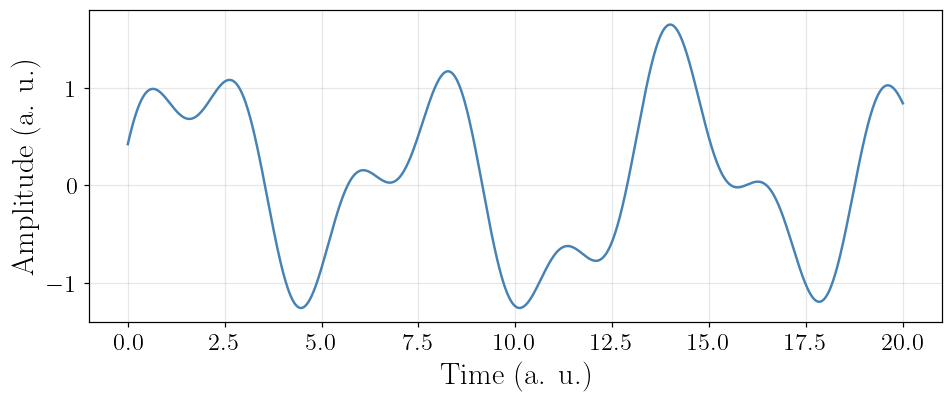

In [4]:
t = np.linspace(0.0, 20.0, 1000)
signal = np.sin(t) + 0.5 * np.sin(2.3 * t + 1.0) + 0.25 * np.sin(0.5 * t)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, signal, color="steelblue")
ax.set_xlabel(r"Time (a. u.)")
ax.set_ylabel(r"Amplitude (a. u.)")
#ax.set_title(r"A general time series")
ax.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, "intro_time_series.pdf")
plt.show()

## 2. What is a peak?

A **peak** (local maximum) is a sample that is larger than its neighbours. We build a
curve from a few Gaussian bumps and mark every peak that `scipy.signal.find_peaks`
locates.

saved ../img/intro_peaks.pdf


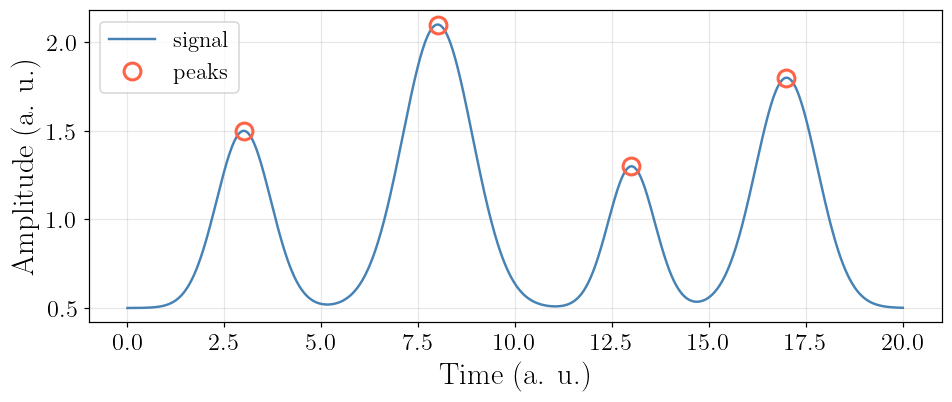

In [5]:
tp = np.linspace(0.0, 20.0, 1000)


def _bump(center, height, width):
    return height * np.exp(-0.5 * ((tp - center) / width) ** 2)


peak_curve = (
    0.5
    + _bump(3.0, 1.0, 0.7)
    + _bump(8.0, 1.6, 0.9)
    + _bump(13.0, 0.8, 0.6)
    + _bump(17.0, 1.3, 0.8)
)

peaks, _ = find_peaks(peak_curve, height=0.8, distance=20)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tp, peak_curve, color="steelblue", label=r"signal")
ax.plot(tp[peaks], peak_curve[peaks], "o", ms=11, mfc="none",
        mec="tomato", mew=2.0, label=r"peaks")
# Annotate the tallest peak.
top = peaks[np.argmax(peak_curve[peaks])]
#ax.annotate(r"peak", xy=(tp[top], peak_curve[top]),
#            xytext=(tp[top] + 1.5, peak_curve[top] + 0.1),
#            arrowprops=dict(arrowstyle="->", color="black"))
ax.set_xlabel(r"Time (a. u.)")
ax.set_ylabel(r"Amplitude (a. u.)")
#ax.set_title(r"Peaks of a signal")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, "intro_peaks.pdf")
plt.show()

## 3. What is an anomaly?

An **anomaly** is a sample that does not follow the *normal* dynamics of the signal.
Here the normal behaviour is a noisy sine; the sparse upward **spikes** are the
anomalies we want to detect.

saved ../img/intro_anomaly.pdf


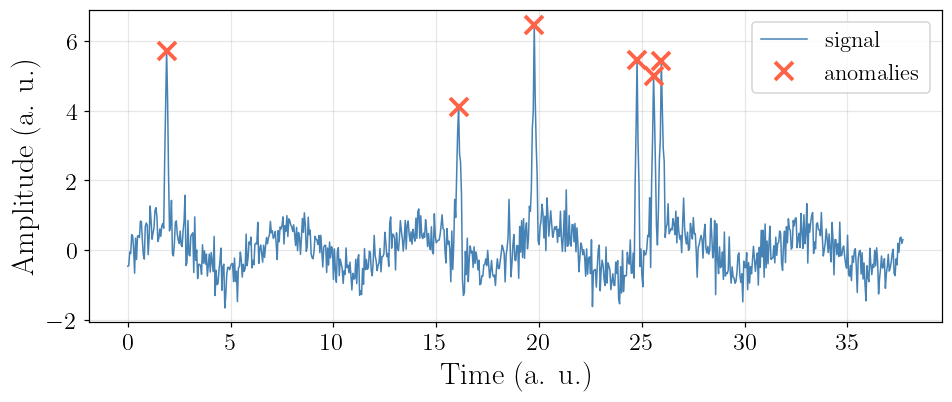

In [6]:
anom_ds = make_anomaly_dataset(
    series_length=800,
    noise_std=0.4,
    x_range=(0.0, 12.0 * math.pi),
    spike_params=SpikeParams(
        amplitude_range=(4.0, 6.0),
        width_range=(2, 3),
        count_range=(5, 7),
        margin=30,
    ),
    random_state=0,
)

a_sig = anom_ds.y[0].numpy()
a_t = anom_ds.t.numpy()
a_pk = anom_ds.peak_indices.numpy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(a_t, a_sig, color="steelblue", lw=1.0, label=r"signal")
ax.plot(a_t[a_pk], a_sig[a_pk], "x", ms=12, mew=2.5, color="tomato",
        label=r"anomalies")
top = a_pk[np.argmax(a_sig[a_pk])]
#ax.annotate(r"anomaly", xy=(a_t[top], a_sig[top]),
#            xytext=(a_t[top] + 2.0, a_sig[top]),
#            arrowprops=dict(arrowstyle="->", color="black"))
ax.set_xlabel(r"Time (a. u.)")
ax.set_ylabel(r"Amplitude (a. u.)")
#ax.set_title(r"Anomalies (spikes) on a sine signal")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, "intro_anomaly.pdf")
plt.show()

## Helper: train `altx` and transform a split

`altx` learns the linear laws obeyed by the *normal* data and turns a series into an
**anomaly score** that is large where those laws are violated. The helpers below cut a
training split into spike-free segments, fit `altx`, and transform any split into a
1-D anomaly score (re-used by Figures 4–6).

In [7]:
RLK = (None, 3, 1)


def train_altx(train, rlk=RLK):
    '''Fit altx on the spike-free segments of a training split.'''
    train_set = train.y.unsqueeze(0)                  # (1, channels, T)
    anomaly_t = (train.labels == 1).nonzero(as_tuple=True)[0].tolist()

    N = train_set.shape[-1]
    boundaries = [-1] + anomaly_t + [N]
    min_seg = 2 * rlk[1]
    segments = []
    for lo, hi in zip(boundaries[:-1], boundaries[1:]):
        start, end = lo + 1, hi
        if end - start >= min_seg:
            segments.append(train_set[..., start:end])

    train_lengths = torch.tensor([seg.shape[-1] for seg in segments])
    max_len = int(train_lengths.max())
    train_segments = torch.cat(
        [F.pad(seg, (0, max_len - seg.shape[-1])) for seg in segments], dim=0
    )
    train_classes = torch.zeros(train_segments.shape[0])

    model = Altx(
        train_set=train_segments,
        train_classes=train_classes,
        train_length=train_lengths,
        R=rlk[0], L=rlk[1], K=rlk[2],
        device=device,
    )
    model.train()
    return model


def altx_score(model, ds):
    '''Transform a split into a 1-D anomaly score (+ aligned t and true peaks).'''
    transformed = model.multiply_only(z=ds.y, rlk=model.RLK[0], normalize_data=False)
    score = (transformed[:, :, 0] ** 2).mean(dim=1).cpu().numpy()
    t = ds.t.numpy()[: score.shape[0]]
    pk = ds.peak_indices.numpy()
    pk = pk[pk < score.shape[0]]
    return score, t, pk

## 4. The data transformed with `altx`

We build a full train / validation / test dataset (as in the benchmark notebook), fit
`altx` on the train split and show the **anomaly score** of the test split. The score
is small where the signal follows the normal dynamics and spikes up at the anomalies.

saved ../img/intro_altx_transformed.pdf


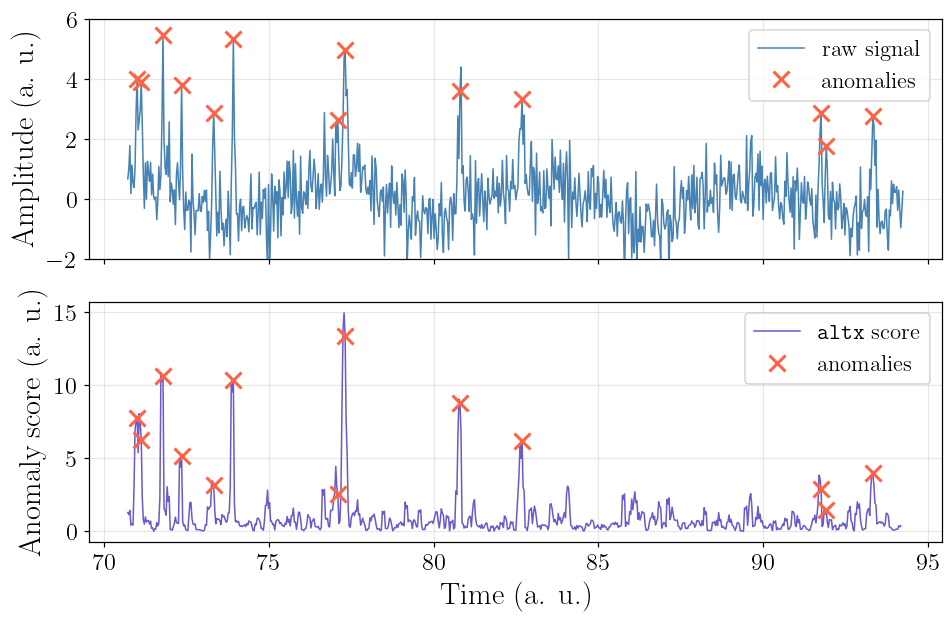

In [8]:
SEED = 5
TOLERANCE = 5

splits = make_anomaly_dataset(
    series_length=3000,
    noise_std=0.7,
    x_range=(0.0, 30.0 * math.pi),
    spike_params=SpikeParams(
        amplitude_range=(2.0, 5.0),
        width_range=(1, 3),
        count_range=(30, 40),
        margin=20,
    ),
    split=(0.5, 0.25, 0.25),
    random_state=SEED,
)
train, val, test = splits.train, splits.val, splits.test

altx_model = train_altx(train)
val_score, val_t, val_peaks = altx_score(altx_model, val)
test_score, test_t, test_peaks = altx_score(altx_model, test)

# Raw test signal vs. its altx transform, on a shared time axis.
raw_sig = test.y[0].numpy()
raw_t = test.t.numpy()
raw_pk = test.peak_indices.numpy()

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(raw_t, raw_sig, color="steelblue", lw=1.0, label=r"raw signal")
axes[0].plot(raw_t[raw_pk], raw_sig[raw_pk], "x", ms=10, mew=2.0,
             color="tomato", label=r"anomalies")
axes[0].set_ylabel(r"Amplitude (a. u.)")
#axes[0].set_title(r"Raw signal vs. \texttt{altx} transform" if USE_TEX
#                  else r"Raw signal vs. altx transform")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-2, 6)

axes[1].plot(test_t, test_score, color="slateblue", lw=1.0,
             label=r"\texttt{altx} score" if USE_TEX else r"altx score")
axes[1].plot(test_t[test_peaks], test_score[test_peaks], "x", ms=10, mew=2.0,
             color="tomato", label=r"anomalies")
axes[1].set_xlabel(r"Time (a. u.)")
axes[1].set_ylabel(r"Anomaly score (a. u.)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

fig.tight_layout()
save_fig(fig, "intro_altx_transformed.pdf")
plt.show()

## 5. Detecting the peaks on the transformed data

We tune `OptimizedFindPeaks` on the transformed **validation** score and run it on the
transformed **test** score. The detected peaks are marked against the ground-truth
anomalies.

saved ../img/intro_altx_detected_peaks.pdf


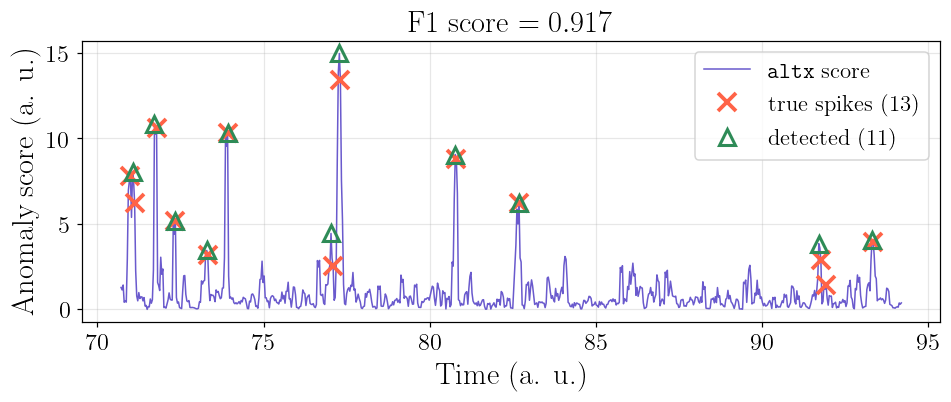

altx test F1: 0.917


In [9]:
altx_opt = OptimizedFindPeaks(scorer="f1", n_trials=200, tolerance=TOLERANCE, seed=SEED)
altx_opt.fit(val_score, val_peaks)

detected_peaks, _ = altx_opt.predict(test_score)
scorer = _make_metric_scorer("f1", TOLERANCE)
test_mask = _as_index_mask(test_peaks, test_score.shape[0])
altx_test_f1 = scorer(test_mask, detected_peaks, test_score.shape[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(test_t, test_score, color="slateblue", lw=1.0,
        label=r"\texttt{altx} score" if USE_TEX else r"altx score")
ax.plot(test_t[test_peaks], test_score[test_peaks], "x", ms=12, mew=2.5,
        color="tomato", label=rf"true spikes ({test_peaks.size})")
ax.plot(test_t[detected_peaks], test_score[detected_peaks], "^", ms=11,
        mfc="none", mec="seagreen", mew=2.0,
        label=rf"detected ({detected_peaks.size})")
ax.set_xlabel(r"Time (a. u.)")
ax.set_ylabel(r"Anomaly score (a. u.)")
ax.set_title(rf"F1 score $= {altx_test_f1:.3f}$")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, "intro_altx_detected_peaks.pdf")
plt.show()
print(f"altx test F1: {altx_test_f1:.3f}")

## 6. F1 score vs. spike amplitude

Finally we compare the two pipelines as the anomalies become more pronounced. For a
range of spike amplitudes $A$ (with `amplitude_range = (A, A + 1)`) we measure the test
F1 of:

* the **raw** baseline — `OptimizedFindPeaks` on the raw signal, and
* the **`altx`** pipeline — `OptimizedFindPeaks` on the `altx` anomaly score.

Each point is repeated over **3 random seeds**; we plot the mean with error bars
showing the standard deviation.

In [10]:
def run_pipeline(amplitude, seed, n_trials=80):
    '''Return (baseline_f1, altx_f1) on the test split for one configuration.'''
    splits = make_anomaly_dataset(
        series_length=3000,
        noise_std=0.7,
        x_range=(0.0, 30.0 * math.pi),
        spike_params=SpikeParams(
            amplitude_range=(amplitude, amplitude + 1.0),
            width_range=(1, 3),
            count_range=(30, 40),
            margin=20,
        ),
        split=(0.5, 0.25, 0.25),
        random_state=seed,
    )
    train, val, test = splits.train, splits.val, splits.test
    scorer = _make_metric_scorer("f1", TOLERANCE)

    def ch0(ds):
        return ds.y[0].numpy()

    # --- Baseline: tune on train+val, evaluate on test (raw signal). ---
    trainval_signal = np.concatenate([ch0(train), ch0(val)])
    trainval_peaks = np.concatenate(
        [train.peak_indices.numpy(), val.peak_indices.numpy() + train.y.shape[1]]
    )
    base_opt = OptimizedFindPeaks(scorer="f1", n_trials=n_trials,
                                  tolerance=TOLERANCE, seed=seed)
    base_opt.fit(trainval_signal, trainval_peaks)
    base_pred, _ = base_opt.predict(ch0(test))
    base_mask = _as_index_mask(test.peak_indices.numpy(), ch0(test).shape[0])
    base_f1 = scorer(base_mask, base_pred, ch0(test).shape[0])

    # --- altx pipeline: fit altx on train, tune on val, evaluate on test. ---
    model = train_altx(train)
    v_score, _, v_peaks = altx_score(model, val)
    t_score, _, t_peaks = altx_score(model, test)
    altx_o = OptimizedFindPeaks(scorer="f1", n_trials=n_trials,
                                tolerance=TOLERANCE, seed=seed)
    altx_o.fit(v_score, v_peaks)
    altx_pred, _ = altx_o.predict(t_score)
    altx_mask = _as_index_mask(t_peaks, t_score.shape[0])
    altx_f1 = scorer(altx_mask, altx_pred, t_score.shape[0])

    return base_f1, altx_f1

In [11]:
amplitudes = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
seeds = [0, 1, 2]
N_TRIALS_STUDY = 80

base_grid = np.zeros((len(amplitudes), len(seeds)))
altx_grid = np.zeros((len(amplitudes), len(seeds)))

for i, amp in enumerate(amplitudes):
    for j, sd in enumerate(seeds):
        b, a = run_pipeline(amp, sd, n_trials=N_TRIALS_STUDY)
        base_grid[i, j] = b
        altx_grid[i, j] = a
        print(f"amp={amp:.1f} seed={sd}: baseline F1={b:.3f}  altx F1={a:.3f}")

base_mean, base_std = base_grid.mean(1), base_grid.std(1)
altx_mean, altx_std = altx_grid.mean(1), altx_grid.std(1)

amp=1.0 seed=0: baseline F1=0.514  altx F1=0.500
amp=1.0 seed=1: baseline F1=0.462  altx F1=0.000
amp=1.0 seed=2: baseline F1=0.320  altx F1=0.240
amp=2.0 seed=0: baseline F1=0.750  altx F1=0.741
amp=2.0 seed=1: baseline F1=0.500  altx F1=0.667
amp=2.0 seed=2: baseline F1=0.737  altx F1=0.588
amp=3.0 seed=0: baseline F1=0.963  altx F1=0.857
amp=3.0 seed=1: baseline F1=0.545  altx F1=0.769
amp=3.0 seed=2: baseline F1=0.706  altx F1=0.667
amp=4.0 seed=0: baseline F1=1.000  altx F1=0.960
amp=4.0 seed=1: baseline F1=1.000  altx F1=0.933
amp=4.0 seed=2: baseline F1=0.952  altx F1=0.842
amp=5.0 seed=0: baseline F1=0.960  altx F1=0.960
amp=5.0 seed=1: baseline F1=0.769  altx F1=0.933
amp=5.0 seed=2: baseline F1=0.952  altx F1=0.706


saved ../img/intro_f1_vs_amplitude.pdf


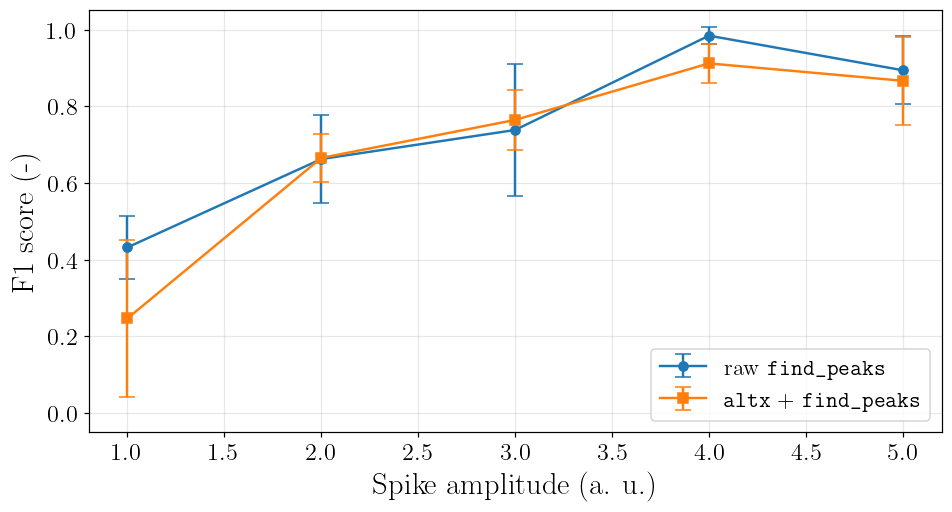

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(amplitudes, base_mean, yerr=base_std, marker="o", capsize=5,
            color="tab:blue", label=r"raw \texttt{find\_peaks}" if USE_TEX
            else r"raw find_peaks")
ax.errorbar(amplitudes, altx_mean, yerr=altx_std, marker="s", capsize=5,
            color="tab:orange", label=r"\texttt{altx} + \texttt{find\_peaks}"
            if USE_TEX else r"altx + find_peaks")
ax.set_xlabel(r"Spike amplitude (a. u.)")
ax.set_ylabel(r"F1 score (-)")
#ax.set_title(r"Detection quality vs. spike amplitude")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
save_fig(fig, "intro_f1_vs_amplitude.pdf")
plt.show()